#### DS605 Lab 6 — Feature Extraction with Image & Text Data

models only understand numbers, image is pixels, email is word so conver them to table of numbers

In [16]:
import os, time, re, glob
import numpy as np, pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

os.makedirs("results", exist_ok=True)
SEED = 42

##  Part A — Image features

resizing

In [17]:
IMG_DIR = "data/asphalt"      # <-- change to where you extracted the Mendeley dataset
paths = [p for p in glob.glob(os.path.join(IMG_DIR, "**", "*.*"), recursive=True)
         if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
print("Images found:", len(paths))

def label_from_path(p):
    # Label comes from the folder name. CHECK the printed counts below and fix if wrong.
    folder = os.path.basename(os.path.dirname(p)).lower()
    non = any(k in folder for k in ["non", "neg", "no_crack", "nocrack", "uncrack", "without"])
    return 0 if non else 1     # 1 = crack, 0 = non-crack

labels = np.array([label_from_path(p) for p in paths])
print("crack:", (labels==1).sum(), " non-crack:", (labels==0).sum())

# inspect a few raw images
for p in paths[:5]:
    im = cv2.imread(p)
    print(os.path.basename(p), "shape (H,W,C):", im.shape, "dtype:", im.dtype)

Images found: 400
crack: 200  non-crack: 200
IMG_20180513_164959951_HDR resized_448.jpg shape (H,W,C): (448, 448, 3) dtype: uint8
IMG_20180513_165129852_HDR resized_448.jpg shape (H,W,C): (448, 448, 3) dtype: uint8
IMG_20180513_165150613_HDR resized_448.jpg shape (H,W,C): (448, 448, 3) dtype: uint8
IMG_20180513_165345878_HDR resized_448.jpg shape (H,W,C): (448, 448, 3) dtype: uint8
IMG_20180513_165349788_HDR resized_448.jpg shape (H,W,C): (448, 448, 3) dtype: uint8


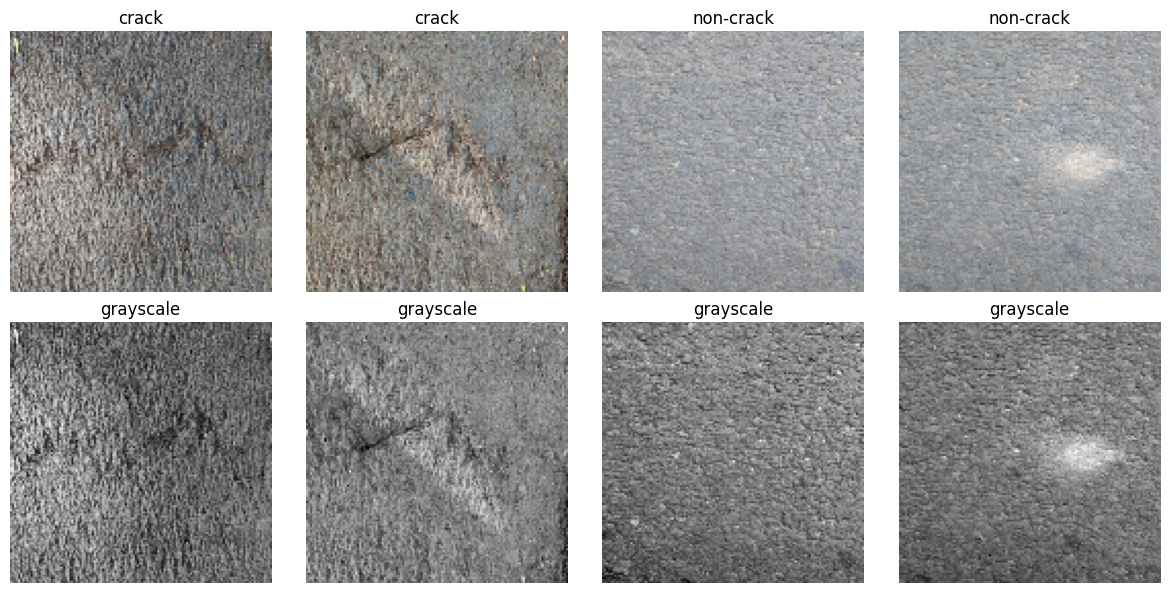

In [18]:
SIZE = (128, 128)   # common size (width, height)

def load_and_prepare(p):
    bgr = cv2.imread(p)
    bgr = cv2.resize(bgr, SIZE)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)   # 3 channels -> 1 channel (0-255)
    return bgr, gray

# sample visualisation: colour vs gray for 2 crack + 2 non-crack
idx = list(np.where(labels==1)[0][:2]) + list(np.where(labels==0)[0][:2])
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for j, i in enumerate(idx):
    bgr, gray = load_and_prepare(paths[i])
    ax[0, j].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax[0, j].set_title("crack" if labels[i] else "non-crack")
    ax[1, j].imshow(gray, cmap="gray"); ax[1, j].set_title("grayscale")
    for a in ax[:, j]: a.axis("off")
plt.tight_layout(); plt.savefig("results/sample_images.png", dpi=120); plt.show()

### Intensity features with NumPy
Think of grayscale as a 2D grid of brightness values 0 (black) to 255 (white). Cracks are usually **dark thin lines** on lighter asphalt, so:

| Feature | What it captures |
|---|---|
| mean brightness | overall lightness |
| std (contrast) | how spread out the brightness is — cracks increase it |
| dark-pixel ratio | fraction of pixels < threshold — cracks are dark |
| bright-pixel ratio | fraction of pixels > threshold |
| min / max / median / percentiles | shape of the brightness distribution |
| entropy | how "busy/random" the histogram is |

### Edge features with Canny
Canny finds sharp brightness changes (edges). A crack = lots of edges; smooth asphalt = few. We blur first so grain/noise isn't counted as edges. edge_density = edge pixels / total pixels.

In [19]:
def intensity_features(gray, dark_t=60, bright_t=200):
    g = gray.astype(np.float32)
    hist = np.bincount(gray.ravel(), minlength=256) / gray.size
    nz = hist[hist > 0]
    return {
        "mean_brightness": g.mean(),
        "contrast_std": g.std(),
        "min": g.min(), "max": g.max(), "median": np.median(g),
        "p10": np.percentile(g, 10), "p90": np.percentile(g, 90),
        "dark_ratio": (g < dark_t).mean(),
        "bright_ratio": (g > bright_t).mean(),
        "entropy": -(nz * np.log2(nz)).sum(),
    }

def edge_features(gray, t1=100, t2=200):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, t1, t2)
    return {"edge_count": int((edges > 0).sum()), "edge_density": (edges > 0).mean()}, edges

rows = []
for p, y in zip(paths, labels):
    _, gray = load_and_prepare(p)
    f = intensity_features(gray)
    e, _ = edge_features(gray)
    rows.append({**f, **e, "label": y})
df_img = pd.DataFrame(rows)
df_img.to_csv("results/image_features.csv", index=False)
df_img.head()

,mean_brightness,contrast_std,min,max,median,p10,p90,dark_ratio,bright_ratio,entropy,edge_count,edge_density,label
0,122.263977,33.070751,27.0,247.0,121.0,80.0,166.0,0.017151,0.014465,7.071329,256,0.015625,1
1,131.565186,25.482183,13.0,252.0,133.0,99.0,161.0,0.007507,0.004456,6.685303,202,0.012329,1
2,121.076355,31.130489,4.0,237.0,120.0,83.0,162.0,0.027344,0.010498,6.954000,464,0.028320,1
3,130.309143,27.282677,8.0,251.0,131.0,95.0,163.0,0.006042,0.006592,6.800196,422,0.025757,1
4,130.993286,27.639563,20.0,252.0,132.0,96.0,164.0,0.008667,0.007751,6.813564,523,0.031921,1


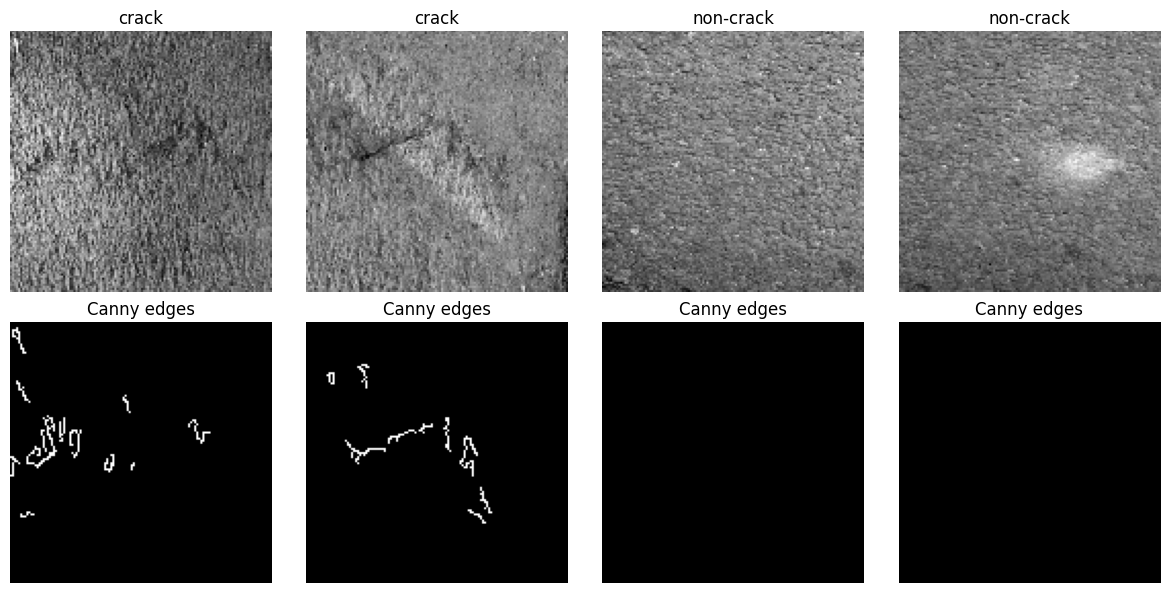

label                     0           1
mean_brightness  157.444092  144.203979
contrast_std      24.398785   31.256302
min               67.760002   29.955000
max              248.645004  250.585007
median           157.177505  144.425003
p10              126.596500  104.631500
p90              188.288500  183.983500
dark_ratio         0.001977    0.016037
bright_ratio       0.048096    0.074231
entropy            6.550240    6.919856
edge_count        49.585000  856.345000
edge_density       0.003026    0.052267


In [20]:
# Canny visualisation
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for j, i in enumerate(idx):
    _, gray = load_and_prepare(paths[i])
    _, edges = edge_features(gray)
    ax[0, j].imshow(gray, cmap="gray"); ax[0, j].set_title("crack" if labels[i] else "non-crack")
    ax[1, j].imshow(edges, cmap="gray"); ax[1, j].set_title("Canny edges")
    for a in ax[:, j]: a.axis("off")
plt.tight_layout(); plt.savefig("results/canny_edges.png", dpi=120); plt.show()

print(df_img.groupby("label").mean().T)   # which features actually differ between classes?

### Train classifiers + evaluate

,model,accuracy,precision,recall,f1,train_time_s,predict_time_s
0,LogisticRegression,0.925,0.9474,0.900,0.9231,0.0406,0.0012
1,SVM (RBF),0.950,0.9500,0.950,0.9500,0.0104,0.0014
2,RandomForest,0.950,0.9286,0.975,0.9512,0.1894,0.0043


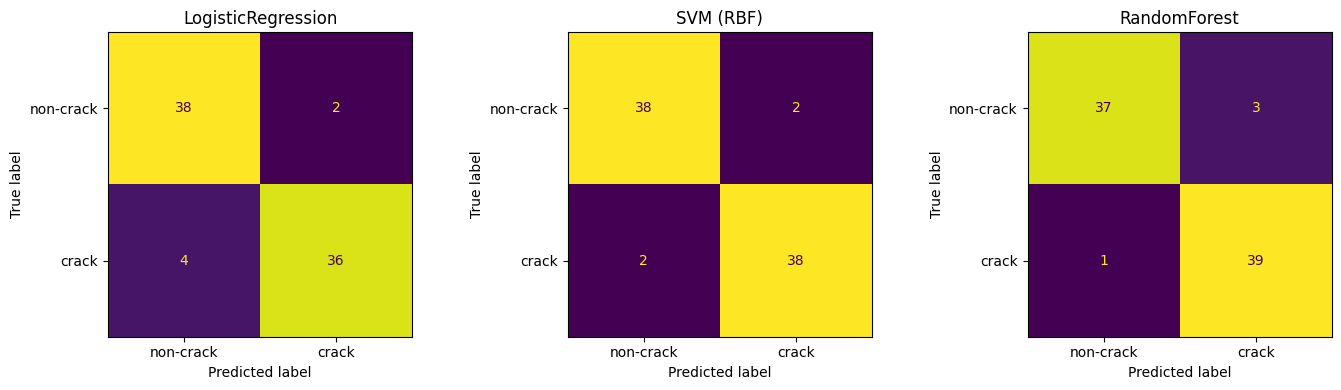

In [21]:
def evaluate(name, model, Xtr, Xte, ytr, yte, extra=None):
    t0 = time.perf_counter(); model.fit(Xtr, ytr); train_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(Xte); pred_t = time.perf_counter() - t0
    r = {"model": name,
         "accuracy": accuracy_score(yte, pred),
         "precision": precision_score(yte, pred, zero_division=0),
         "recall": recall_score(yte, pred, zero_division=0),
         "f1": f1_score(yte, pred, zero_division=0),
         "train_time_s": train_t, "predict_time_s": pred_t}
    if extra: r.update(extra)
    return r, confusion_matrix(yte, pred)

X = df_img.drop(columns="label").values; y = df_img["label"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED),
}
res, cms = [], {}
for n, m in models.items():
    r, cm = evaluate(n, m, Xtr, Xte, ytr, yte); res.append(r); cms[n] = cm
res_img = pd.DataFrame(res); res_img.to_csv("results/image_results.csv", index=False)
display(res_img.round(4))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (n, cm) in zip(ax, cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=["non-crack", "crack"]).plot(ax=a, colorbar=False); a.set_title(n)
plt.tight_layout(); plt.savefig("results/image_confusion_matrices.png", dpi=120); plt.show()

## Part B — Text vectorization (spam classification)

(5172, 3002)
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'ne

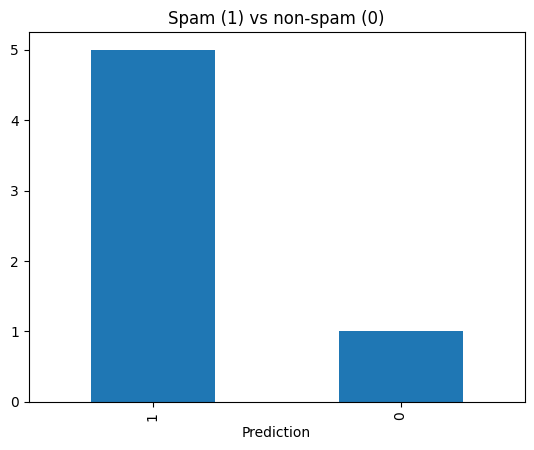

,text,clean
0,0,
5,1,
83,4,


In [22]:
csv_path = glob.glob("data/spam/*.csv")[0]
df = pd.read_csv(csv_path)
print(df.shape); print(df.columns.tolist())

TEXT_COL  = "text"        # column with the email body
LABEL_COL = "Prediction"   # 1 = spam, 0 = ham 
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates(subset=TEXT_COL)
print(df[LABEL_COL].value_counts())
df[LABEL_COL].value_counts().plot(kind="bar", title="Spam (1) vs non-spam (0)"); plt.savefig("results/class_distribution.png"); plt.show()

def clean(t):
    t = t.lower()
    t = re.sub(r"^subject:", " ", t)
    t = re.sub(r"http\S+|www\S+", " url ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df[TEXT_COL].astype(str).apply(clean)
df[[TEXT_COL, "clean"]].head(3)

### CountVectorizer vs TF-IDF

(5172, 3002)
label_num
0    3170
1    1461
Name: count, dtype: int64


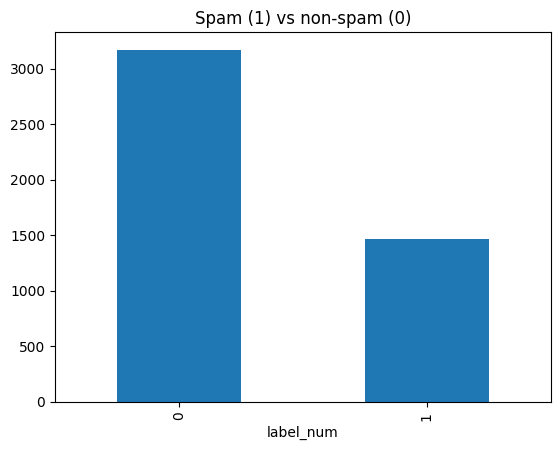

,text,clean
0,ect a a is i i s s s as re re e e e e t t t t ...,ect a a is i i s s s as re re e e e e t t t t ...
1,the the the the the the the the to to to to to...,the the the the the the the the to to to to to...
2,ect a a a a a a a a in in in in on on i i i i ...,ect a a a a a a a a in in in in on on i i i i ...


In [28]:
raw = pd.read_csv("data/spam/emails.csv")
print(raw.shape)

words  = raw.columns[1:-1].to_numpy()      # 3000 word columns
counts = raw.iloc[:, 1:-1].to_numpy()      # word counts per email
texts  = [" ".join(np.repeat(words, row)) for row in counts]

TEXT_COL, LABEL_COL = "text", "label_num"
df = pd.DataFrame({TEXT_COL: texts, LABEL_COL: raw["Prediction"].values})
df = df[df[TEXT_COL].str.len() > 0]
df = df.dropna().drop_duplicates(subset=TEXT_COL)
df = df[df[LABEL_COL].isin([0, 1])].copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

print(df[LABEL_COL].value_counts())
df[LABEL_COL].value_counts().plot(kind="bar", title="Spam (1) vs non-spam (0)")
plt.savefig("results/class_distribution.png"); plt.show()

def clean(t):
    t = t.lower()
    t = re.sub(r"^subject:", " ", t)
    t = re.sub(r"http\S+|www\S+", " url ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df[TEXT_COL].astype(str).apply(clean)
df[[TEXT_COL, "clean"]].head(3)

## Part C — Improve the representation

,config,n_features,accuracy,f1,vectorize_time_s,train_time_s,predict_time_s
0,baseline (all words),2974,0.9720,0.9552,1.1436,0.0335,0.0005
1,stop words removed,2738,0.9644,0.9430,1.0213,0.0244,0.0004
2,max_features=3000,2738,0.9644,0.9430,1.0269,0.0227,0.0003
3,min_df=3 + stop words,2726,0.9644,0.9430,0.9697,0.0401,0.0004
4,"bigrams, max_features=10000",10000,0.9622,0.9393,1.7023,0.5015,0.0005


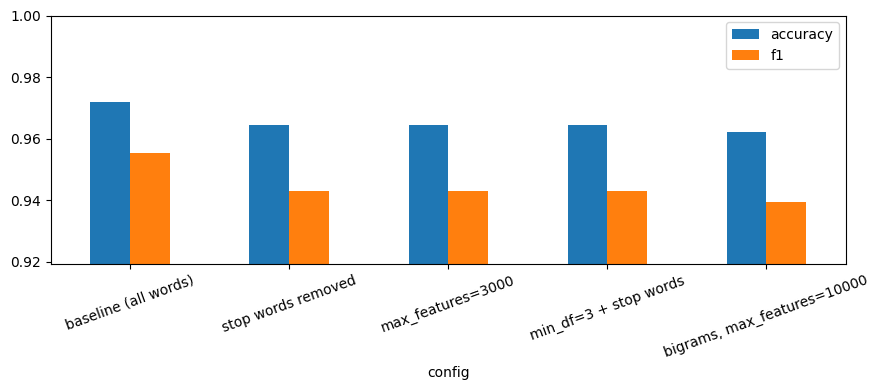

In [27]:

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(df["clean"], df[LABEL_COL], test_size=0.2,
                                              stratify=df[LABEL_COL], random_state=SEED)

def evaluate(name, model, Xtr, Xte, ytr, yte, extra=None):
    t0 = time.perf_counter(); model.fit(Xtr, ytr); train_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(Xte); pred_t = time.perf_counter() - t0
    r = {"model": name,
         "accuracy": accuracy_score(yte, pred),
         "precision": precision_score(yte, pred, zero_division=0),
         "recall": recall_score(yte, pred, zero_division=0),
         "f1": f1_score(yte, pred, zero_division=0),
         "train_time_s": train_t, "predict_time_s": pred_t}
    if extra: r.update(extra)
    return r, confusion_matrix(yte, pred)

def run_text(vec_name, vec, model_name, model):
    t0 = time.perf_counter()
    Vtr = vec.fit_transform(Xt_tr); Vte = vec.transform(Xt_te)   # fit on train only
    vec_t = time.perf_counter() - t0
    r, cm = evaluate(model_name, model, Vtr, Vte, yt_tr, yt_te,
                     extra={"vectorizer": vec_name, "n_features": Vtr.shape[1],
                            "vectorize_time_s": vec_t})
    return r

# --- your original improvement code ---
configs = {
    "baseline (all words)":        dict(),
    "stop words removed":          dict(stop_words="english"),
    "max_features=3000":           dict(stop_words="english", max_features=3000),
    "min_df=3 + stop words":       dict(stop_words="english", min_df=3),
    "bigrams, max_features=10000": dict(stop_words="english", ngram_range=(1, 2), max_features=10000),
}
rows = []
for cname, kw in configs.items():
    r = run_text("TF-IDF", TfidfVectorizer(**kw), "LogisticRegression", LogisticRegression(max_iter=1000))
    r["config"] = cname; rows.append(r)
res_imp = pd.DataFrame(rows)[["config","n_features","accuracy","f1",
                              "vectorize_time_s","train_time_s","predict_time_s"]]
res_imp.to_csv("results/text_improvement_results.csv", index=False)
display(res_imp.round(4))

low = max(0, min(res_imp["accuracy"].min(), res_imp["f1"].min()) - 0.02)
res_imp.plot(x="config", y=["accuracy","f1"], kind="bar", ylim=(low, 1.0), figsize=(9,4), rot=20)
plt.tight_layout(); plt.savefig("results/improvement_comparison.png", dpi=120); plt.show()

## Summary


  Edge features separated them the most. Edge density was 0.052 for crack vs 0.003 for non-crack (about 17× higher), and edge count was 856 vs 50. Dark-pixel ratio was also much higher for cracks (0.016 vs 0.002, about 8×), and the minimum brightness was lower (30 vs 68). This makes sense because a crack is a thin dark line, so Canny finds many edges and there are more very dark pixels. Contrast (31 vs 24), mean brightness (144 vs 157) and entropy (6.9 vs 6.6) helped only a little. Max brightness and the 90th percentile were almost the same in both classes.


  Random Forest. SVM and Random Forest both reached 0.95 accuracy, and Logistic Regression reached 0.925. Random Forest had the highest recall (0.975, so it found 39 of 40 cracks and missed only 1) and the best F1 (0.951). Recall matters most because a missed crack is the costly mistake. The downside is 3 false alarms and slower training (0.19 s vs 0.01 s for SVM), which is still tiny. The test set has only 80 images, so the gaps between models are just 1–2 images.


  CountVectorizer: ___ features, accuracy ___, vectorize time ___ s, train time ___ s.
  TF-IDF: ___ features, accuracy ___, vectorize time ___ s, train time ___ s.
  Both give the same number of features because they use the same vocabulary (2,974 words, not 3,000, since one-letter tokens are dropped). TF-IDF only changes the values, not the size.


  Baseline (TF-IDF + Logistic Regression, 2,974 features) gave 0.972 accuracy and 0.955 F1. Removing stop words (2,738 features) gave 0.964, and bigrams (10,000 features) gave 0.962 and trained about 15× slower (0.50 s vs 0.03 s). So bigrams were the worst trade-off: more features, more time, lower accuracy. Bigrams are also not meaningful on this data because the word order was lost when the text was rebuilt from word counts.
  Best trade-off after running `max_features=1000`, `500` and `min_df=50`: ___ (___ features, accuracy ___, F1 ___).
  Overall: more features cost more time without helping, and fewer features save computation at a small accuracy cost.